# LAB2 Exercise 3 - Fine Tuning a CLIP model
**Author:** Edoardo Canti<br>

This exercise is divided into:
1. Exploratory Data Analysis of the dataset
2. Evaluate CLIP zero shot performances
3. The CLIP Fine Tuning itself
4. Results
---

# 1) Exploratory Data Analysis
## Disclaimer

**Why this dataset?** <br>
The interest was to find a dataset related to *Document Images* (scans of different types of documents).<br>
I personally think that a switch of the model's original domain would have been interesting, especially because **CLIP** works with images and texts, since it is not reasonable at all to think that it will perform by recognizing characters (i.e: the content), the interest here is to understand if CLIP will be able to discriminate between the documents **layouts**!<br>
<br>
The original idea was to use (the huge!) [rvl-cdip](https://huggingface.co/datasets/aharley/rvl_cdip?utm_source=chatgpt.com) but I found some problems related to conda and hugging face version, also the dataset was about 38 Gb so I decided to switch to a smaller dataset suggested by Gemini. <br>
<br>
So the chosen dataset has been: [tobacco3482](https://huggingface.co/datasets/maveriq/tobacco3482)
<br>
<br>
**What is it about?**<br>
[tobacco3482](https://huggingface.co/datasets/maveriq/tobacco3482) contains 3482 *(...)* Document Images<br>
divided into 10 classes related to: advertisments, scientific literature, news and other (will be shown later)

In [5]:
from datasets import load_dataset
import torch
import os
from torch.utils.data import Dataset, DataLoader
from peft import get_peft_model, LoraConfig
from transformers import pipeline
from IPython.display import display
import random
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import json
from transformers import AutoProcessor, AutoModel
import wandb

import sys
sys.path.append(os.path.abspath('..'))


from utils.helpers_functions import (get_configuration, zero_shot_random_image, evaluate_clip, 
                                    preprocess_in_batches, build_lora_model, set_seed, train_peft_model)


config = get_configuration("config.yaml")
print(config)

CLIP_VARS = config['CLIP']
CLIP_VARS

if torch.cuda.is_available():
    device = torch.device("cuda")     
elif torch.backends.mps.is_available():
    device = torch.device("mps")      
else:
    device = torch.device("cpu")
print("Selected device: {}".format(device))

seed = set_seed(int(CLIP_VARS['SEED']))
print("Execution setted over seed: {}".format(seed))

# Since Dataloader of both validation and training use shuffle I need to set the seed
dataloader_gen = torch.Generator()
dataloader_gen.manual_seed(seed)

{'DATA': {'slug': 'cornell-movie-review-data/rotten_tomatoes'}, 'MODEL': {'slug': 'distilbert/distilbert-base-uncased'}, 'EXEC': {'recompute_embeddings': False, 'training_cls_embeddings_path': 'artifacts/training_cls_embeddings.pt', 'test_cls_embeddings_path': 'artifacts/test_cls_embeddings.pt', 'vali_cls_embeddings_path': 'artifacts/val_cls_embeddings.pt'}, 'SVC': {'random_state': 99, 'c_regularizer_lowerbound': '1e-5', 'c_regularizer_upperbound': 1}, 'TOKENIZED_DATA': {'save_path': 'artifacts/tokenized_data/tokenized_data.pt', 'exec_tokenization': False}, 'FINE_TUNING_PHASE': {'learning_rate': [2e-05, 2e-06], 'batch_size': [16, 64], 'optimizers': ['adamw_torch', 'sgd'], 'run_hpo': False, 'best_model_path': './hpo_results/run_lr_2e-05_bs_64_opt_adamw_torch/checkpoint-402'}, 'CLIP': {'SEED': 99, 'DATA_SLUG': 'maveriq/tobacco3482', 'CLIP_MODEL_SLUG': 'openai/clip-vit-base-patch16', 'CLIP_TASK': 'zero-shot-image-classification', 'RUN_CLIP_PREPROCESS': True, 'FT_EPOCHS': 10, 'FT_LR': '1e-

In [6]:
dataset = load_dataset(CLIP_VARS['DATA_SLUG'])
dataset
# ds['train']['image'][0] # Accessing to the first image
# dataset['train'][3450]['label'] # Accessing the label of the -th element

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 3482
    })
})

In [7]:
all_labels = dataset['train']['label']
labels_names = all_labels.features.names
labels_names

['ADVE',
 'Email',
 'Form',
 'Letter',
 'Memo',
 'News',
 'Note',
 'Report',
 'Resume',
 'Scientific']

In [8]:
class_cardinality_dict = dict()

for i in range(len(labels_names)):
    class_cardinality_dict[labels_names[i]] = all_labels.count(i)

class_cardinality_dict

{'ADVE': 230,
 'Email': 599,
 'Form': 431,
 'Letter': 567,
 'Memo': 620,
 'News': 188,
 'Note': 201,
 'Report': 265,
 'Resume': 120,
 'Scientific': 261}

In [9]:
# After some printings the dataset result sorted by class (integers)
# I want to shuffe it
dataset = dataset.shuffle(seed = seed)
dataset['train']['label']

Column([2, 7, 4, 9, 7])

---
## 2) CLIP zero shot classification
### What happens if we pass this dataset to a **CLIP** zero shot classification pipeline using these labels?

### Textual Embeddings 
**CLIP** is composed of a **Textual Encoder** and an **Image Encoder**<br>
<br>
Here we want to define the **prompts** that, **AT INFERENCE**, are going to be passed to the **Textual Encoder**

**NOTE:** These prompts will be preprocessed automatically if we use the HF-pipeline

In [10]:
# Defining the prompts to be passed to the model
BASE_PROMPT = "A scanned image representing a {} document"
prompts = [BASE_PROMPT.format(lbl) for lbl in labels_names]
prompts

['A scanned image representing a ADVE document',
 'A scanned image representing a Email document',
 'A scanned image representing a Form document',
 'A scanned image representing a Letter document',
 'A scanned image representing a Memo document',
 'A scanned image representing a News document',
 'A scanned image representing a Note document',
 'A scanned image representing a Report document',
 'A scanned image representing a Resume document',
 'A scanned image representing a Scientific document']

In [11]:
dataset['train'].num_rows

3482

### Randomly select and Image and apply zero shot (demonstration)

#### Set this as True if you want to see the document image inside jupyter notebook.

In [12]:
SHOW_IMGS_IN_NOOTEBOOK = True

Device set to use mps


CLIP predictions: [{'score': 0.3524264097213745, 'label': 'A scanned image representing a Report document'}, {'score': 0.18841588497161865, 'label': 'A scanned image representing a Scientific document'}, {'score': 0.1498633772134781, 'label': 'A scanned image representing a Memo document'}, {'score': 0.08436980843544006, 'label': 'A scanned image representing a Resume document'}, {'score': 0.07271134853363037, 'label': 'A scanned image representing a News document'}, {'score': 0.04379962757229805, 'label': 'A scanned image representing a Note document'}, {'score': 0.04137676954269409, 'label': 'A scanned image representing a Letter document'}, {'score': 0.028728825971484184, 'label': 'A scanned image representing a ADVE document'}, {'score': 0.027835533022880554, 'label': 'A scanned image representing a Form document'}, {'score': 0.010472366586327553, 'label': 'A scanned image representing a Email document'}]
Real class: Letter
The image: 



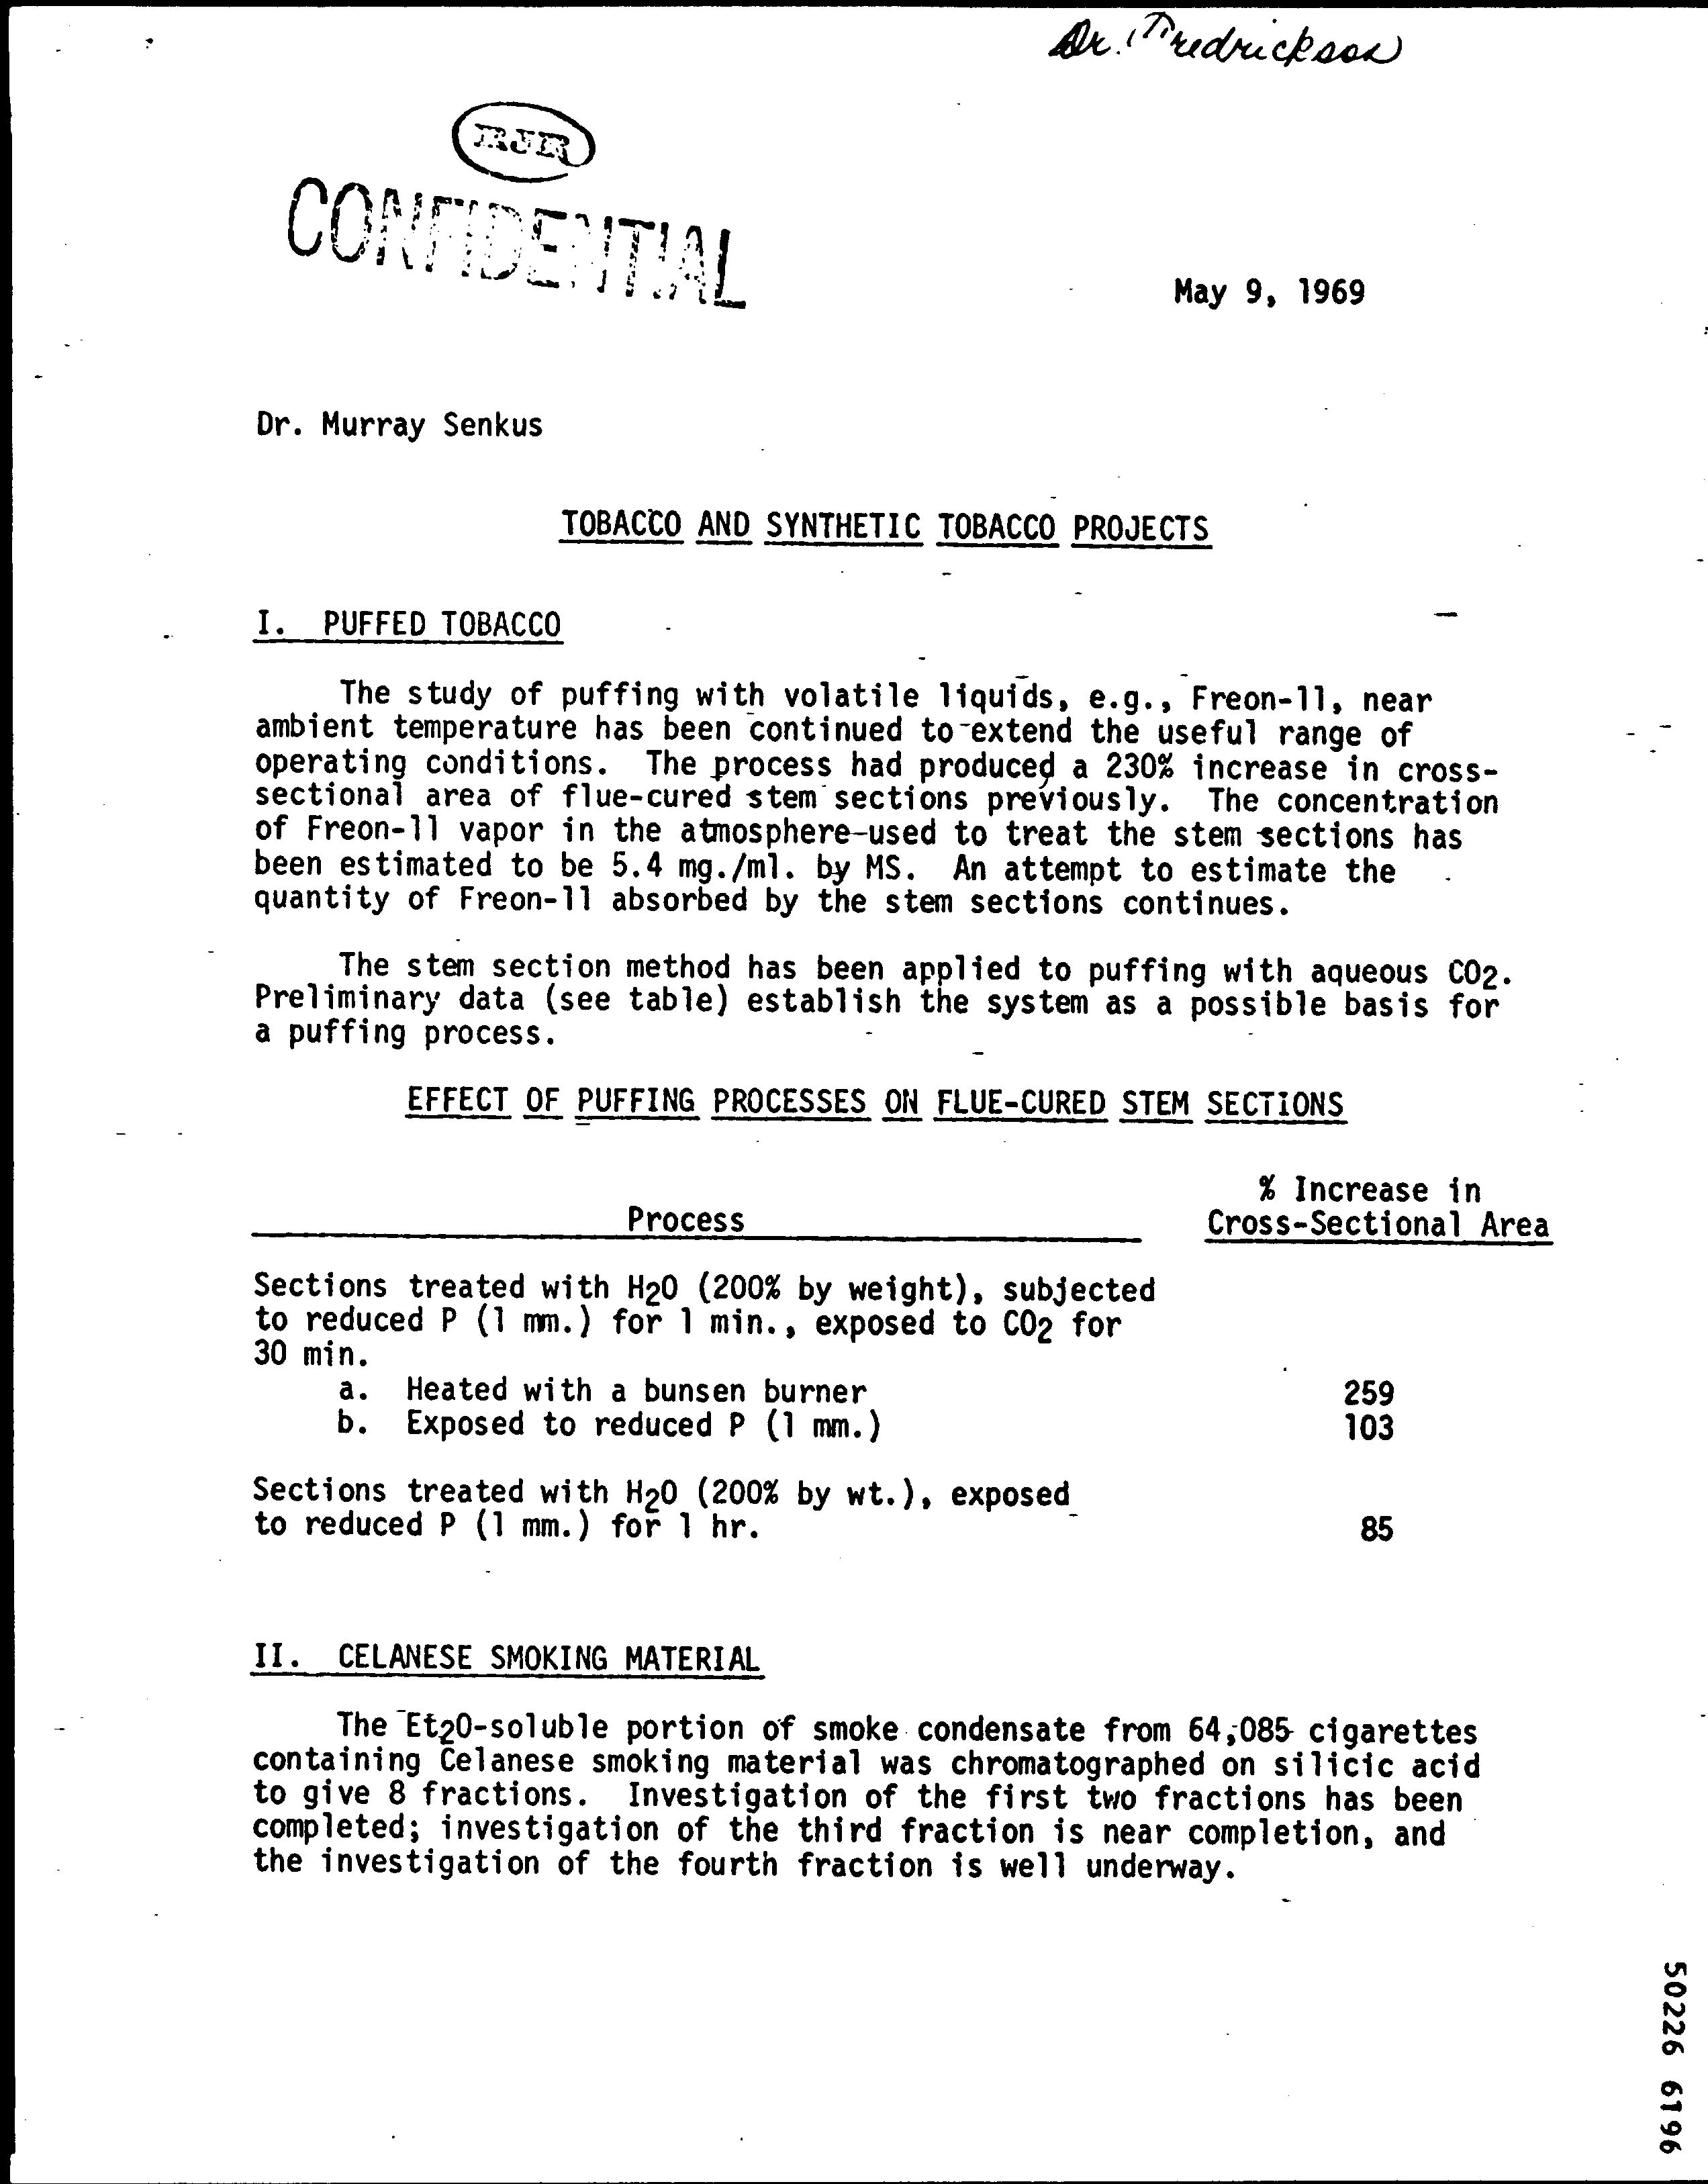

In [13]:
clip = pipeline(model = CLIP_VARS['CLIP_MODEL_SLUG'], task=CLIP_VARS['CLIP_TASK'], device=device)

predictions, y_true, img = zero_shot_random_image(dataset, clip, prompts)

print("CLIP predictions: {}".format(predictions))
print("Real class: {}".format(labels_names[y_true]))
if SHOW_IMGS_IN_NOOTEBOOK:
    print("The image: \n")
    display(img)
else:
    print("Opening image outside this notebook: \n")
    img.show()

### CLIP Performances on zero shot classification
Evaluating CLIP performances over all the dataset

In [15]:
y_trues, y_preds, ptts, results = evaluate_clip(dataset['train'], clip, labels_names, prompts)

CLIP zero shot on tobacco3843:   7%|▋         | 253/3482 [00:28<05:41,  9.46it/s]

> 250 images passed



CLIP zero shot on tobacco3843:  14%|█▍        | 502/3482 [00:56<05:24,  9.17it/s]

> 250 images passed



CLIP zero shot on tobacco3843:  22%|██▏       | 753/3482 [01:25<04:37,  9.82it/s]

...

CLIP zero shot on tobacco3843:  86%|████████▌ | 3002/3482 [05:41<01:02,  7.69it/s]

> 250 images passed



CLIP zero shot on tobacco3843:  93%|█████████▎| 3252/3482 [06:10<00:28,  7.98it/s]

> 250 images passed



CLIP zero shot on tobacco3843: 100%|██████████| 3482/3482 [06:35<00:00,  8.81it/s]


In [28]:
# results # Commented in order to avoid console spam
report = classification_report(y_trues, y_preds, labels=labels_names)
print(report)

              precision    recall  f1-score   support

        ADVE       0.34      0.06      0.10       230
       Email       0.60      0.02      0.03       599
        Form       1.00      0.00      0.00       431
      Letter       0.53      0.56      0.54       567
        Memo       0.38      0.41      0.39       620
        News       0.50      0.84      0.63       188
        Note       0.95      0.17      0.29       201
      Report       0.13      0.32      0.18       265
      Resume       0.09      0.68      0.16       120
  Scientific       0.47      0.52      0.49       261

    accuracy                           0.31      3482
   macro avg       0.50      0.36      0.28      3482
weighted avg       0.53      0.31      0.28      3482



In [29]:
accuracy = accuracy_score(y_trues, y_preds)
accuracy

0.311889718552556

In [13]:
os.makedirs("../experiments/RESULTS_TOBACCO_ZERO_SHOT", exist_ok=True)

with open("../experiments/RESULTS_TOBACCO_ZERO_SHOT/results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

with open("../experiments/RESULTS_TOBACCO_ZERO_SHOT/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)


--- 

## 3) Fine Tuning

First we take a closer look to the model

In [14]:
# Before we used the pipeline, now we are not allowed to do that so:
clip_model = AutoModel.from_pretrained(CLIP_VARS['CLIP_MODEL_SLUG'])
clip_processor = AutoProcessor.from_pretrained(CLIP_VARS['CLIP_MODEL_SLUG'])

**REMEMBER THAT SINCE WE ARE NOT USING THE PIPELINE ANYMORE WE NEED TO CALL THE PREPROCESSOR ON BOTH IMAGES AND TEXTS!**

In [15]:
clip_model

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e

We can clearly see two distinct components:
 1. **text_model**
 2. **vision_model**

**text_model**: Appears as an encoder only transformer, which is actually a series of 12 stacked encoders.<br>
It seems to use a self-attention mechanism described as CLIPSdpaAttention, that implements torch scaled dot product attention <br>
as shown in [the documentation](https://huggingface.co/microsoft/LLM2CLIP-Openai-B-16/blob/main/modeling_clip.py) (I didn't investigate deeper than this, but this seems the classic Vaswani's attention with different vector spaces for Q,K,V extrapolated from "the same" input matrix X).<br>
Also there are normalization layers and MLP.
<br>
<br>

**vision_model**: There is no reason to be redundant here, we could say that the vision_model is *"just"* the vision counterpart of what we just said [An Image is Worth 16x16 Words...](https://arxiv.org/pdf/2010.11929).

Let's take a minute to reflect on what we are going to do:<br>
We decided to use a not aligned dataset of document images that has for each document image a label consisting of the type of the document itself.<br><br>
As expected, **CLIP** didn't perform very well on zero-shot classification... <br><br>
**Can we improve its performances?**<br>
Well it is clearly not reasonable to apply a fine tuning to the whole model, so we can use **Parameter Efficient Fine Tuning**<br><br>

How to correctly use HuggingFace PEFT is based on the [official documentation](https://huggingface.co/docs/peft/quicktour)

### Data preparation
First of all we need to decompose the dataset into training and test by considering class stratification <br>
In this case I'm not going to perform **HPO**, especially because the dataset is not big enough, I could apply some<br>
augmentations (I was thinking for instance to use *Augraphy* in order to create noisey versions of the input, but tbh <br> it would have take time and probably goind out-of-theme)

In [16]:
train_test_split = dataset['train'].train_test_split(test_size=0.2, seed=99, stratify_by_column='label')
train_test_split

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2785
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 697
    })
})

In [17]:
train_val_split = train_test_split['train'].train_test_split(test_size=0.1, seed=99, stratify_by_column="label")
train_val_split

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2506
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 279
    })
})

In [18]:
X_train = train_val_split['train']['image']
y_train = train_val_split['train']['label'] # remember that these are numbers
text_train = []
for item in y_train:
    text_train.append(prompts[item])

X_val = train_val_split['test']['image']
y_val = train_val_split['test']['label'] # remember that these are numbers
text_val = []
for item in y_val:
    text_val.append(prompts[item])

X_test = train_test_split['test']['image']
y_test = train_test_split['test']['label'] # remember that these are numbers
text_test = []
for item in y_test:
    text_test.append(prompts[item])

In [19]:
print(text_train[:5])
print("---")
print(text_val[:5])
print("---")
print(text_test[:5])

['A scanned image representing a Memo document', 'A scanned image representing a Form document', 'A scanned image representing a Note document', 'A scanned image representing a Resume document', 'A scanned image representing a Email document']
---
['A scanned image representing a Scientific document', 'A scanned image representing a Email document', 'A scanned image representing a News document', 'A scanned image representing a ADVE document', 'A scanned image representing a Letter document']
---
['A scanned image representing a Email document', 'A scanned image representing a Scientific document', 'A scanned image representing a Form document', 'A scanned image representing a Memo document', 'A scanned image representing a Form document']


In [20]:
# As we saw during lecture we can pass to the processor (from AutoProcessor) the padding param
# MY_EXAMPLES = ["This is text", "This is another text!"]
# inputs = clip_processor(MY_EXAMPLES, return_tensors='pt', padding = True)
# paddings pads by it own

**CHOOSE IF RUN CLIP PREPROCESSING OR LOAD EXSISTING:**

In [21]:
RUN_CLIP_PREPROCESS = CLIP_VARS['RUN_CLIP_PREPROCESS']
clip_preprocessed_inputs_dir = "../artifacts/clip_inputs"
train_path = os.path.join(clip_preprocessed_inputs_dir, "train_inputs.pt")
val_path = os.path.join(clip_preprocessed_inputs_dir, "val_inputs.pt")
test_path = os.path.join(clip_preprocessed_inputs_dir, "test_inputs.pt")
os.makedirs(clip_preprocessed_inputs_dir, exist_ok=True)

In [22]:
if RUN_CLIP_PREPROCESS: 
    print("Preprocessing inputs for CLIP")
    train_inputs = preprocess_in_batches(X_train, text_train, clip_processor, batch_size=100)
    torch.save(train_inputs, train_path)
    val_inputs = preprocess_in_batches(X_val, text_val, clip_processor, batch_size = 100)
    torch.save(val_inputs, val_path)
    test_inputs = preprocess_in_batches(X_test, text_test, clip_processor, batch_size=100)
    torch.save(test_inputs, test_path)
else:
    train_inputs = torch.load(train_path)
    val_inputs = torch.load(val_path)
    test_inputs = torch.load(test_path)
    print("Loaded inputs for CLIP")

Preprocessing inputs for CLIP


In [ ]:
class TobaccoDataset(Dataset):

    def __init__(self, inputs):
        self.pixel_values = inputs["pixel_values"]
        self.input_ids = inputs["input_ids"]
        
    def __len__(self):
        return len(self.input_ids)
        
    def __getitem__(self, i):
        return {"pixel_values": self.pixel_values[i],"input_ids": self.input_ids[i]}

In [24]:
train_dataloader = DataLoader(TobaccoDataset(train_inputs), batch_size=16, shuffle=True, generator=dataloader_gen)
val_dataloader = DataLoader(TobaccoDataset(val_inputs), batch_size=16, shuffle=False)
test_dataloader = DataLoader(TobaccoDataset(test_inputs), batch_size=16, shuffle=False)

### Applying LoRA to Text Encoder Only

In [25]:
# FINE TUNING PARAMS
FT_EPOCHS = int(CLIP_VARS['FT_EPOCHS'])
FT_LR = float(CLIP_VARS['FT_LR'])
FT_BS = int(CLIP_VARS['FT_BS'])

In [26]:
peft_text_encoder, clip_processor, text_modules = build_lora_model(CLIP_VARS['CLIP_MODEL_SLUG'], device, model_component="text_model")

trainable params: 393,216 || all params: 150,013,953 || trainable%: 0.2621


In [27]:
peft_text_encoder = train_peft_model(peft_text_encoder, train_dataloader, val_dataloader, 
                 CLIP_VARS['PROJECT_NAME'], 'LoRA_CLIP_TEXT_ENCODER', FT_LR, FT_EPOCHS, FT_BS, device)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
wandb: Currently logged in as: edoardo-canti (edoardo-canti-). Use `wandb login --relogin` to force relogin
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. D

Epoch 0: Train Loss: 1.864132997336661, Val Loss: 1.5694327851136525;
Epoch 1: Train Loss: 1.6106037000182327, Val Loss: 1.4855499896738265;
Epoch 2: Train Loss: 1.541582061986255, Val Loss: 1.4645879003736708;
Epoch 3: Train Loss: 1.488873553124203, Val Loss: 1.4625782171885173;
Epoch 4: Train Loss: 1.4919906425627933, Val Loss: 1.4493891795476277;
Epoch 5: Train Loss: 1.476369223397249, Val Loss: 1.4193314611911774;
Epoch 6: Train Loss: 1.4625404723890267, Val Loss: 1.4059439334604475;
Epoch 7: Train Loss: 1.4504172111013134, Val Loss: 1.4084898233413696;
Epoch 8: Train Loss: 1.432496304344979, Val Loss: 1.3935991956128015;
Epoch 9: Train Loss: 1.4482805926329012, Val Loss: 1.3797532220681508;


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▂▂▂▁▁▁▁
val_loss,█▅▄▄▄▂▂▂▂▁
epoch,10
train_loss,1.44828
val_loss,1.37975


In [28]:
pipe_text = pipeline("zero-shot-image-classification", model=peft_text_encoder, tokenizer=clip_processor.tokenizer,
    image_processor=clip_processor.image_processor, device=device)


y_true_names, y_pred_names, probs_to_true_names, results = evaluate_clip(dataset_split=train_test_split['test'],
    model=pipe_text, labels_names=labels_names, prompts=prompts)

Device set to use mps
The model 'PeftModel' is not supported for zero-shot-image-classification. Supported models are ['AlignModel', 'AltCLIPModel', 'BlipModel', 'Blip2ForImageTextRetrieval', 'ChineseCLIPModel', 'CLIPModel', 'CLIPSegModel', 'SiglipModel'].
CLIP zero shot on tobacco3843:  36%|███▌      | 252/697 [00:29<00:50,  8.75it/s]

> 250 images passed



CLIP zero shot on tobacco3843:  72%|███████▏  | 502/697 [00:58<00:21,  9.15it/s]

> 250 images passed



CLIP zero shot on tobacco3843: 100%|██████████| 697/697 [01:21<00:00,  8.57it/s]


In [29]:
report = classification_report(y_true_names, y_pred_names, labels=labels_names)
print(report)

              precision    recall  f1-score   support

        ADVE       1.00      0.96      0.98        46
       Email       0.92      0.95      0.93       120
        Form       0.83      0.79      0.81        86
      Letter       0.70      0.76      0.73       114
        Memo       0.76      0.45      0.57       124
        News       0.94      0.84      0.89        38
        Note       0.73      0.82      0.78        40
      Report       0.43      0.70      0.53        53
      Resume       0.96      0.92      0.94        24
  Scientific       0.60      0.69      0.64        52

    accuracy                           0.76       697
   macro avg       0.79      0.79      0.78       697
weighted avg       0.78      0.76      0.76       697



In [30]:
accuracy = accuracy_score(y_true_names, y_pred_names)
accuracy

0.7589670014347202

In [31]:
os.makedirs("../experiments/RESULTS_TOBACCO_CLIP_TEXT_FINETUNED", exist_ok=True)

with open("../experiments/RESULTS_TOBACCO_CLIP_TEXT_FINETUNED/results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

with open("../experiments/RESULTS_TOBACCO_CLIP_TEXT_FINETUNED/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

### Applying LoRA to Vision Encoder Only

In [32]:
peft_vision_encoder, clip_processor, vision_modules = build_lora_model(CLIP_VARS['CLIP_MODEL_SLUG'], device, model_component="vision_model")

trainable params: 589,824 || all params: 150,210,561 || trainable%: 0.3927


In [33]:
peft_vision_encoder = train_peft_model(peft_vision_encoder, train_dataloader, val_dataloader, 
                 CLIP_VARS['PROJECT_NAME'], 'LoRA_CLIP_VISION_ENCODER', FT_LR, FT_EPOCHS, FT_BS, device)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch 0: Train Loss: 2.111348565976331, Val Loss: 1.658802694744534;
Epoch 1: Train Loss: 1.5753751962807527, Val Loss: 1.3772981762886047;
Epoch 2: Train Loss: 1.3629034639923436, Val Loss: 1.2791745993826125;
Epoch 3: Train Loss: 1.2521764153887511, Val Loss: 1.2204190459516313;
Epoch 4: Train Loss: 1.1757225352487746, Val Loss: 1.1879185603724585;
Epoch 5: Train Loss: 1.134619819890162, Val Loss: 1.1769559284051259;
Epoch 6: Train Loss: 1.0754348685027688, Val Loss: 1.182463526725769;
Epoch 7: Train Loss: 1.0548802306697627, Val Loss: 1.1875188383791182;
Epoch 8: Train Loss: 1.0217467360435777, Val Loss: 1.1734344396326277;
Epoch 9: Train Loss: 1.0167958144169704, Val Loss: 1.1919783155123393;


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▅▃▃▂▂▁▁▁▁
val_loss,█▄▃▂▁▁▁▁▁▁
epoch,10
train_loss,1.0168
val_loss,1.19198


In [34]:
#Exception: Impossible to guess which image processor to use.
pipe_vision = pipeline("zero-shot-image-classification", model=peft_vision_encoder, tokenizer=clip_processor.tokenizer, 
                       image_processor=clip_processor.image_processor, device=device)


y_true_names, y_pred_names, probs_to_true_names, results = evaluate_clip(dataset_split=train_test_split['test'],
    model=pipe_vision, labels_names=labels_names, prompts=prompts)

Device set to use mps
The model 'PeftModel' is not supported for zero-shot-image-classification. Supported models are ['AlignModel', 'AltCLIPModel', 'BlipModel', 'Blip2ForImageTextRetrieval', 'ChineseCLIPModel', 'CLIPModel', 'CLIPSegModel', 'SiglipModel'].
CLIP zero shot on tobacco3843:  36%|███▌      | 252/697 [00:30<00:51,  8.66it/s]

> 250 images passed



CLIP zero shot on tobacco3843:  72%|███████▏  | 502/697 [01:00<00:21,  8.91it/s]

> 250 images passed



CLIP zero shot on tobacco3843: 100%|██████████| 697/697 [01:22<00:00,  8.44it/s]


In [35]:
report = classification_report(y_true_names, y_pred_names, labels=labels_names)
print(report)

              precision    recall  f1-score   support

        ADVE       0.97      0.83      0.89        46
       Email       0.98      0.99      0.98       120
        Form       0.95      0.71      0.81        86
      Letter       0.82      0.94      0.87       114
        Memo       0.89      0.81      0.85       124
        News       0.82      0.95      0.88        38
        Note       0.86      0.80      0.83        40
      Report       0.65      0.62      0.63        53
      Resume       0.63      0.92      0.75        24
  Scientific       0.69      0.83      0.75        52

    accuracy                           0.85       697
   macro avg       0.83      0.84      0.83       697
weighted avg       0.86      0.85      0.85       697



In [36]:
accuracy = accuracy_score(y_true_names, y_pred_names)
accuracy

0.8479196556671449

In [37]:
os.makedirs("../experiments/RESULTS_TOBACCO_CLIP_VISION_FINETUNED", exist_ok=True)

with open("../experiments/RESULTS_TOBACCO_CLIP_VISION_FINETUNED/results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

with open("../experiments/RESULTS_TOBACCO_CLIP_VISION_FINETUNED/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

### Applying LoRA to both Text and Vision Encoder

In [38]:
peft_encoder, clip_processor, text_modules = build_lora_model(CLIP_VARS['CLIP_MODEL_SLUG'], device, model_component="all")

trainable params: 983,040 || all params: 150,603,777 || trainable%: 0.6527


In [39]:
peft_encoder = train_peft_model(peft_encoder, train_dataloader, val_dataloader, 
                 CLIP_VARS['PROJECT_NAME'], 'LoRA_CLIP_ENCODERS', FT_LR, FT_EPOCHS, FT_BS, device)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch 0: Train Loss: 1.7364160490643448, Val Loss: 1.3111051751507654;
Epoch 1: Train Loss: 1.3264389668300653, Val Loss: 1.1784088247352176;
Epoch 2: Train Loss: 1.2140088741946373, Val Loss: 1.1313918862077925;
Epoch 3: Train Loss: 1.1272699210294492, Val Loss: 1.1057895488209195;
Epoch 4: Train Loss: 1.0736115590022628, Val Loss: 1.1107389860683017;
Epoch 5: Train Loss: 1.030695156686625, Val Loss: 1.0952941576639812;
Epoch 6: Train Loss: 1.0175152200802116, Val Loss: 1.0916394591331482;
Epoch 7: Train Loss: 0.9899194597438642, Val Loss: 1.1053862207465701;
Epoch 8: Train Loss: 0.9741368908791026, Val Loss: 1.1056700150171916;
Epoch 9: Train Loss: 0.9659676217729118, Val Loss: 1.0999797566069498;


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▂▂▂▁▁▁▁
val_loss,█▄▂▁▂▁▁▁▁▁
epoch,10
train_loss,0.96597
val_loss,1.09998


In [40]:
pipe = pipeline("zero-shot-image-classification", model=peft_encoder, tokenizer=clip_processor.tokenizer, 
                       image_processor=clip_processor.image_processor, device=device)


y_true_names, y_pred_names, probs_to_true_names, results = evaluate_clip(dataset_split=train_test_split['test'],
    model=pipe, labels_names=labels_names, prompts=prompts)

Device set to use mps
The model 'PeftModel' is not supported for zero-shot-image-classification. Supported models are ['AlignModel', 'AltCLIPModel', 'BlipModel', 'Blip2ForImageTextRetrieval', 'ChineseCLIPModel', 'CLIPModel', 'CLIPSegModel', 'SiglipModel'].
CLIP zero shot on tobacco3843:  36%|███▌      | 252/697 [00:31<00:56,  7.86it/s]

> 250 images passed



CLIP zero shot on tobacco3843:  72%|███████▏  | 502/697 [01:02<00:22,  8.55it/s]

> 250 images passed



CLIP zero shot on tobacco3843: 100%|██████████| 697/697 [01:27<00:00,  7.99it/s]


In [41]:
report = classification_report(y_true_names, y_pred_names, labels=labels_names)
print(report)

              precision    recall  f1-score   support

        ADVE       1.00      0.87      0.93        46
       Email       0.98      0.99      0.98       120
        Form       0.89      0.93      0.91        86
      Letter       0.88      0.94      0.91       114
        Memo       0.89      0.91      0.90       124
        News       0.90      0.92      0.91        38
        Note       0.85      0.88      0.86        40
      Report       0.67      0.60      0.63        53
      Resume       0.88      0.88      0.88        24
  Scientific       0.82      0.71      0.76        52

    accuracy                           0.89       697
   macro avg       0.88      0.86      0.87       697
weighted avg       0.89      0.89      0.89       697



In [42]:
accuracy = accuracy_score(y_true_names, y_pred_names)
accuracy

0.8880918220946915

In [43]:
os.makedirs("../experiments/RESULTS_TOBACCO_CLIP_FINETUNED", exist_ok=True)

with open("../experiments/RESULTS_TOBACCO_CLIP_FINETUNED/results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

with open("../experiments/RESULTS_TOBACCO_CLIP_FINETUNED/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

---

## 4) Results

Although [Radford et al. (2021)](http://proceedings.mlr.press/v139/radford21a/radford21a.pdf) don't report the exact composition of the dataset used during training, **section 2.2** cites as *"mainly used dataset in reasearch"* MSCOCO, Visual Genome and YFCC100M, also reports that other systems uses instagram photos. These quotes suggest, at the very least, that the authors were primarily interested in images representing "ordinary photos". They also says that the so-called WebImagesText (WIT) was built by crawling the web for images relatives to texts that represents concepts that appears at least 100 times in English Wikipedia (footnote 1 of section 2.2).<br>
<br>
This introduction is intended in order to make it plausible that it is not rational to assume that the original dataset contained a large number of scanned documents with the relevant label. <br>
<br>
<br>
The work presented here want to show the progress made by fine tuning different **CLIP modules** alternatively and together.

<br>
<br>
Precision p on class C: the probability that, when model says C, the element is actually a C<br>
Recall p on class C: of all possible Cs, how many were actually classified as C? <br>
F1: mean on Preicision and Recall<br>
Accuracy: of all docs, how many were actuallt guessed? 

### 4.1) Clip zero shot on Tobacco3482

In this section the basic **CLIP model**, **not fine tuned**, was used in order to classify tobacco dataset images in *zero shot classification*, CLIP allows the user to present a list of *candidate_labels* that the model will try to attach to each image.

The following table shows the classification report result contained in *RESULTS_TOBACCO_ZERO_SHOT*:

|  | Precision | Recall | F1-score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **ADVE** | 0.34 | 0.06 | 0.10 | 230 |
| **Email** | 0.60 | 0.02 | 0.03 | 599 |
| **Form** | 1.00 | 0.00 | 0.00 | 431 |
| **Letter** | 0.53 | 0.56 | 0.54 | 567 |
| **Memo** | 0.38 | 0.41 | 0.39 | 620 |
| **News** | 0.50 | 0.84 | 0.63 | 188 |
| **Note** | 0.95 | 0.17 | 0.29 | 201 |
| **Report** | 0.13 | 0.32 | 0.18 | 265 |
| **Resume** | 0.09 | 0.68 | 0.16 | 120 |
| **Scientific** | 0.47 | 0.52 | 0.49 | 261 |
| **Accuracy** | - | - | 0.31 | 3482 |
| **Macro avg** | 0.50 | 0.36 | 0.28 | 3482 |
| **Weighted avg** | 0.53 | 0.31 | 0.28 | 3482 |

These results partially seems to confirm what has been said in the introduction, **CLIP** model appears not trained to recognize the type of the document images based on its description (and vice versa). This is confirmed by an overall **accuracy of 31%**
<br>

In this case the **worst performances** are obatined over *Forms*, *Email* and *Adve*
<br>
While the **best** are obtained over *News*, *Letters* and *Scientific*


### 4.2) Clip Text Encoder - only Fine Tuned on Tobacco3482

Maintaining the Vision Encoder as it is means to do not modify the images structures learnt during the original training phase.<br>
In this experiment the goal is to understand if CLIP "knows" what a document layout is visually, but it doesn't "know" what the document class is actually.<br>
<br>
It is not easy to make consideration in these kind of experiments: <br><br> If by freezing the Vision Encoder, the performances are good it means that, the visual features learnt during pre-training by CLIP, are enough to understand the Document Images. This could be reasonable in the sense that: despite the fact that (potentially) the original training set of CLIP is trained over "common images", it could have learn the "shallow" representation of complex common images  and could somehow reflect those patterns in a simple document image (trying to make an example here: a complex picture of a country field could have an horizontal component representing the background separation of the field and the sky and the document image layout could have an intestation inside the document that appears as an horizontal feature. TBH I would be more familiar to visualize this example in the context of CNN, but I think it could be reasonable).

The following table shows the classification report result contained in *RESULTS_TOBACCO_CLIP_TEXT_FINETUNED* (please note that the support is different because, by fine tuning, it was necessary to divide the original tobacco dataset into training, validation and test)
| | Precision | Recall | F1-score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **ADVE** | 1.00 | 0.96 | 0.98 | 46 |
| **Email** | 0.92 | 0.95 | 0.93 | 120 |
| **Form** | 0.83 | 0.79 | 0.81 | 86 |
| **Letter** | 0.70 | 0.76 | 0.73 | 114 |
| **Memo** | 0.76 | 0.45 | 0.57 | 124 |
| **News** | 0.94 | 0.84 | 0.89 | 38 |
| **Note** | 0.73 | 0.82 | 0.78 | 40 |
| **Report** | 0.43 | 0.70 | 0.53 | 265 |
| **Resume** | 0.96 | 0.92 | 0.94 | 24 |
| **Scientific** | 0.60 | 0.69 | 0.64 | 52 |
| **Accuracy** | - | - | 0.76 | 697 |
| **Macro avg** | 0.79 | 0.79 | 0.78 | 697 |
| **Weighted avg** | 0.78 | 0.76 | 0.76 | 697 |

The results show a substantial improvement in performances: <br>
*Advertisments*, *Resumes* and *Emails* appears as the best classified.<br>
<br>
In tobacco Datasets *adverstiments* are basically images with some writings, they are *more similar* to "common images" (e.g: in this case there will be an advertisement of a pack of cigarettes, also if CLIP would never have seen a pack of cigarettes into its training set, at least it will know what a rectangular box looks like), probably (due to the nature of the dataset itself) CLIP had no attitude to associate a rectangular box to the class "Cigarettes advertisement", because it is not reasonable (for what we said in the introduction) that it could have been a common concept during the web scraping phase. <br>
<br>
It seems more difficult to provide an intepretation to the other results, what I personally would expect (partially based on what just said) is that lower accuracy performances should be attached to classes that representes documents with not homogeneous layout within classes (handwrittens memos for example), but in extreme synthesis this could be also in contrast with what was said about advertisements.

![Training vs Validation Loss in Clip-Text Encoder Fine Tuning](https://raw.githubusercontent.com/edoardocanti/DeepLearningApplications/main/LAB2_TheTransformativeTransformer/imgs/loss_text_encoder.png "Clip Text Encoder Training vs Validation loss")

### 4.3) CLIP Vision Encoder - only Fine Tuned on Tobacco3482

Maintaining the Text Encoder as it is means not modifying the semantic and the concepts learned during CLIP's original pre-training phase.

In this experiment, the goal is to understand if CLIP already "knows" what the document classes conceptually mean through text, but lacks the specific visual representation to properly extract and interpret the layout of a document image.

These are the results:
| | Precision | Recall | F1-score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **ADVE** | 0.97 | 0.83 | 0.89 | 46 |
| **Email** | 0.98 | 0.99 | 0.98 | 120 |
| **Form** | 0.95 | 0.71 | 0.81 | 86 |
| **Letter** | 0.82 | 0.94 | 0.87 | 114 |
| **Memo** | 0.89 | 0.81 | 0.85 | 124 |
| **News** | 0.94 | 0.85 | 0.88 | 38 |
| **Note** | 0.86 | 0.80 | 0.83 | 40 |
| **Report** | 0.65 | 0.62 | 0.63 | 53 |
| **Resume** | 0.63 | 0.92 | 0.75 | 24 |
| **Scientific** | 0.69 | 0.83 | 0.75 | 52 |
| **Accuracy** | - | - | 0.85 | 697 |
| **Macro avg** | 0.83 | 0.84 | 0.83 | 697 |
| **Weighted avg** | 0.86 | 0.85 | 0.85 | 697 |

Fine-tuning the Vision Encoder alone outperforms the text-only approach. As previously noted, a performance gap of this magnitude was not entirely expected. While general spatial features may be partially captured from complex images during zero-shot pre-training, fine-tuning the vision encoder directly allows the model to learn much deeper and more complex representations of document layouts.

![Training vs Validation Loss in Clip-Vision Encoder Fine Tuning](https://raw.githubusercontent.com/edoardocanti/DeepLearningApplications/main/LAB2_TheTransformativeTransformer/imgs/loss_vision_encoder.png "Clip Vision Encoder Training vs Validation loss")

### 4.4) CLIP Fine Tuned on Tobacco3482

|  | Precision | Recall | F1-score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **ADVE** | 1.00 | 0.87 | 0.93 | 46 |
| **Email** | 0.98 | 0.99 | 0.98 | 120 |
| **Form** | 0.89 | 0.93 | 0.91 | 86 |
| **Letter** | 0.88 | 0.94 | 0.91 | 114 |
| **Memo** | 0.89 | 0.91 | 0.90 | 124 |
| **News** | 0.90 | 0.92 | 0.91 | 38 |
| **Note** | 0.85 | 0.88 | 0.86 | 40 |
| **Report** | 0.67 | 0.60 | 0.63 | 53 |
| **Resume** | 0.88 | 0.88 | 0.88 | 24 |
| **Scientific** | 0.82 | 0.71 | 0.76 | 52 |
| **Accuracy** | - | - | 0.89 | 697 |
| **Macro avg** | 0.88 | 0.86 | 0.87 | 697 |
| **Weighted avg** | 0.89 | 0.89 | 0.89 | 697 |

Now both CLIP modules are fine tuned. <br>
This means that at the same time:
  * Clip learnt how to represent the text "A scanned image representing a [some class] document"
  * Also learnt which new geometry extracted should be attached to the text representation above.

<br>
This brings to a total increment of the zero shot baseline of 0.58 (thats massive!). <br>
<br>

For what we say prevously we see that the increment is not additive (but also remember that the zero shot baseline was applied to a different support).

<br>
<br>

Watching the results we can conclude that **for this particular task** the *Vision Encoder* is predominant. <br>
I'm not completely sure on how to interpret this, but I think it is worth to consider the following:<br>
if we take a look at the new candidates labels (the prompts), by construction, they have been define with the same stem:<br>

*'A scanned image representing a ADVE document'*, *'A scanned image representing a Email document'*. <br>
fine tuning the text encoder only on these reduced set of labels probably is not bringing that much, because, with the frozen vision model, it will still use the "complex images" patterns to anchor the correct image to the correct representation of a label that is (probably) very similar (and close) in the latent space to the representation of an incorrect label.<br>

At the same time, forcing the model to focus on the documents image layout, while also defining the new textual representations that are attached to them, brings to more precise performances on classification tasks.

![Training vs Validation Loss in Clip Both Encoders Fine Tuning](https://raw.githubusercontent.com/edoardocanti/DeepLearningApplications/main/LAB2_TheTransformativeTransformer/imgs/loss_both_encoders.png "Clip Both Encoders Training vs Validation loss")

The following image is a full visualization of Training and Validation losses trends accross all experiments:
<br><br>

![Training vs Validation Loss in Clip comparison](https://raw.githubusercontent.com/edoardocanti/DeepLearningApplications/main/LAB2_TheTransformativeTransformer/imgs/full_comparison.png "Clip comparison")